##### ARTI 560 - Computer Vision

## Image Classification with Vision Transformer (ViT) - Exercise

### Objective

In this exercise, you will test the pretrained Vision Transformer (ViT) model on 5 real-world images that you find online.

You will:

1. Download 5 images for different classes in [ImageNet](https://github.com/Waikato/wekaDeeplearning4j/blob/master/docs/user-guide/class-maps/IMAGENET.md).

2. Load the ImageNet class names from a [text file](https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt).

3. Use ViT to predict the class for each image.

4. Record whether the prediction was correct.

#### Important Note

For this exercise, you MUST use the following KerasHub components:

- [keras_hub.models.ViTImageClassifier](https://keras.io/keras_hub/api/models/vit/vit_image_classifier/)

- [keras_hub.models.ViTImageClassifierPreprocessor](https://keras.io/keras_hub/api/models/vit/vit_image_classifier_preprocessor/)

This ensures your input preprocessing (resizing + normalization) matches what the pretrained ViT model expects.

Do not replace the preprocessor with manual normalization (such as dividing by 255), because it may produce incorrect predictions.

In [8]:
# Import Libraries
import tensorflow as tf
from tensorflow import keras
from keras import layers
import keras_hub #provides pretrained models like: ViT, Bert
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load ViTImageClassifierPreprocessor (vit_base_patch16_224_imagenet preset)
preprocessor = keras_hub.models.ViTImageClassifierPreprocessor.from_preset("vit_base_patch16_224_imagenet")

In [3]:
# Load ViTImageClassifierPreprocessor (vit_base_patch16_224_imagenet preset)

# Pretrained ViT classifier
vit = keras_hub.models.ViTImageClassifier.from_preset(
    "vit_base_patch16_224_imagenet",
    preprocessor = preprocessor
    )


In [6]:
# Load the images
classes_url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
classes_path = tf.keras.utils.get_file('imagenet_classes.txt', classes_url)
with open(classes_path) as f:
    imagenet_classes = [line.strip() for line in f.readlines()]


10472/10472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Image File      | Predicted Label
----------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
tench-fish.jpg  | tench


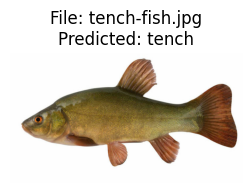

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
BaldEagle.jpg   | bald eagle


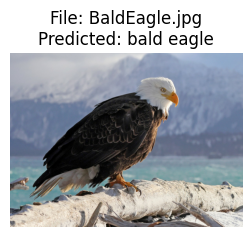

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
Hammerhead.png  | hammerhead


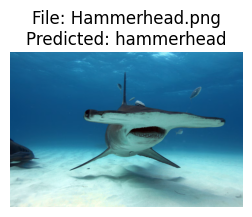

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step
AmericanRobin.jpg | robin


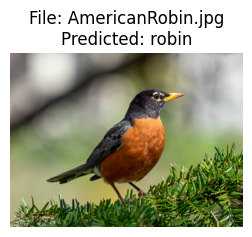

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
Goldfish.jpg    | goldfish


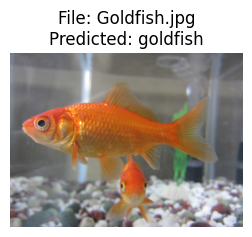

In [15]:
# Predict classes
def predict_image(image_paths):
    print(f"{'Image File':<15} | {'Predicted Label'}")
    print("-" * 40)
    for path in image_paths:
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        predictions = vit.predict(tf.expand_dims(img, axis=0))
        predicted_idx = np.argmax(predictions, axis=-1)[0]
        label = imagenet_classes[predicted_idx]
        file_name = path.split('/')[-1]
        print(f"{file_name:<15} | {label}")
        plt.figure(figsize=(3, 3))
        plt.imshow(img)
        plt.title(f"File: {file_name}\nPredicted: {label}")
        plt.axis('off')
        plt.show()

import os
folder_path = '/content/Images'
image_list = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.endswith(('.jpg', 'png','.jpeg'))]
predict_image(image_list)

### Record Your Results

Fill the table below based on your results:

| Image File   | Predicted Label | True Label (What you searched) | Correct? (Yes/No) |

| tench-fish.jpg |---- Tench -----| -------- Tench ---------------|-------- Yes -------|

| BaldEagle.jpg  |-- BaldEagle ---|---------- BaldEagle -----------|------- Yes -------|

| Hammerhead.png |-- Hammerhead---|--------- Hammerhead -----------|------- Yes -------|

| AmericanRobin.jpg|---- robin ---|--------- AmericanRobin --------|------- Yes -------|

| Goldfish.jpg   |--- goldfish ---|--------- goldfish -------------|------- Yes -------|

